In [1]:
print("Hello, World!")

Hello, World!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

In [3]:
ROOT_DIR = Path("..")

pokemon_path = ROOT_DIR / "data" / "raw" / "pokemon_complete.csv"
types_path = ROOT_DIR / "data" / "raw" / "pokemon_types.csv"

pokemon_df = pd.read_csv(pokemon_path)
types_df = pd.read_csv(types_path)

print("Pokemon Shape",pokemon_df.shape)
print("Types Shape", types_df.shape)

Pokemon Shape (1350, 31)
Types Shape (18, 7)


In [4]:
pokemon_df.info()
types_df.info()

pokemon_df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pokedex_number      1350 non-null   int64  
 1   name                1350 non-null   str    
 2   type_1              1350 non-null   str    
 3   type_2              765 non-null    str    
 4   hp                  1350 non-null   int64  
 5   attack              1350 non-null   int64  
 6   defense             1350 non-null   int64  
 7   sp_attack           1350 non-null   int64  
 8   sp_defense          1350 non-null   int64  
 9   speed               1350 non-null   int64  
 10  base_stat_total     1350 non-null   int64  
 11  height_m            1350 non-null   float64
 12  weight_kg           1350 non-null   float64
 13  base_experience     1302 non-null   float64
 14  abilities           1325 non-null   str    
 15  hidden_ability      988 non-null    str    
 16  generation       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pokedex_number,1350.0,NaN,NaN,NaN,2836.148148,4135.53196,1.0,338.25,675.5,1012.75,10325.0
name,1350,1350,Bulbasaur,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_1,1350,18,Water,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_2,765,18,Flying,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hp,1350.0,NaN,NaN,NaN,71.671852,26.837396,1.0,55.0,70.0,85.0,255.0
attack,1350.0,NaN,NaN,NaN,82.783704,32.350046,5.0,60.0,80.0,102.75,190.0
defense,1350.0,NaN,NaN,NaN,76.194074,30.724283,5.0,55.0,70.0,95.0,250.0
sp_attack,1350.0,NaN,NaN,NaN,75.368148,33.989075,10.0,50.0,69.0,97.0,216.0
sp_defense,1350.0,NaN,NaN,NaN,74.095556,27.801487,20.0,54.0,70.0,90.0,250.0
speed,1350.0,NaN,NaN,NaN,71.961481,30.620661,5.0,49.0,70.0,94.75,200.0


In [5]:
missing_pokemon = (
    pokemon_df
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_pokemon["missing_percentage"] = (
    missing_pokemon["missing_count"] / len(pokemon_df) * 100
).round(2)

missing_pokemon.sort_values(by="missing_percentage", ascending=False)

,column,missing_count,missing_percentage
23,habitat,830,61.48
3,type_2,585,43.33
15,hidden_ability,362,26.81
30,sprite_url,60,4.44
13,base_experience,48,3.56
14,abilities,25,1.85
2,type_1,0,0.00
6,defense,0,0.00
5,attack,0,0.00
7,sp_attack,0,0.00


In [6]:
print("Duplicate Pokemon:", pokemon_df.duplicated().sum())
print("Duplicate Pokemon Names:", pokemon_df['name'].duplicated().sum())
print("Duplicate Pokemon Number:", pokemon_df['pokedex_number'].duplicated().sum())

Duplicate Pokemon: 0
Duplicate Pokemon Names: 0
Duplicate Pokemon Number: 0


,type_1,count
0,Water,160
1,Normal,139
2,Grass,122
3,Electric,100
4,Bug,95
5,Psychic,85
6,Fire,84
7,Rock,83
8,Dark,63
9,Fighting,62


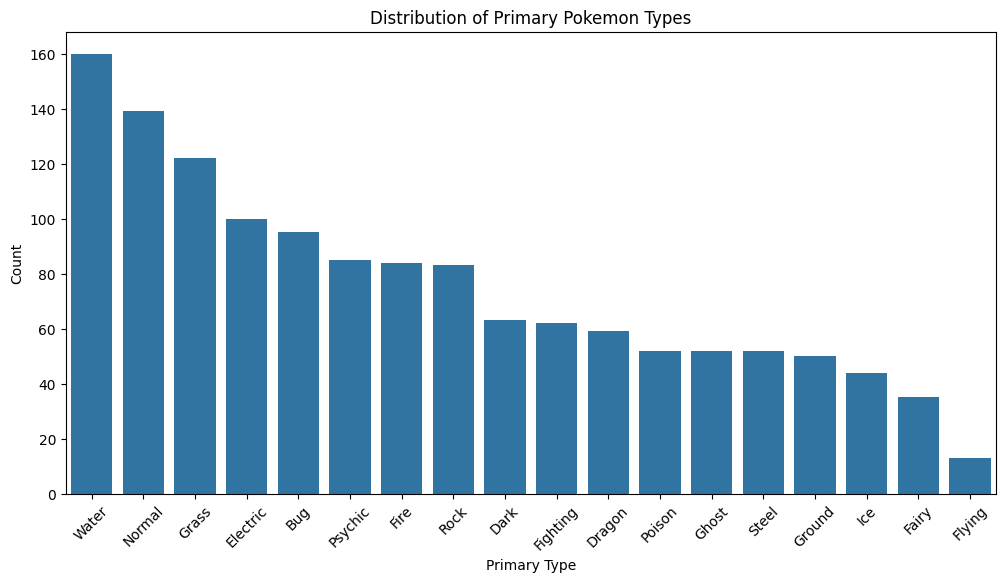

In [9]:
type_1_count = pokemon_df['type_1'].value_counts().reset_index()
type_1_count.columns = ['type_1', 'count']

display(type_1_count)

plt.figure(figsize=(12, 6))
sns.barplot(data=type_1_count, x='type_1', y='count')
plt.xticks(rotation=45)
plt.title('Distribution of Primary Pokemon Types')
plt.xlabel('Primary Type')
plt.ylabel('Count')
plt.show()

In [10]:
type_2_count = pokemon_df["type_2"].value_counts(dropna=False).reset_index()
type_2_count.columns = ["type_2", "count"]

display(type_2_count)

,type_2,count
0,NaN,585
1,Flying,141
2,Dragon,58
3,Psychic,56
4,Poison,54
5,Fairy,53
6,Fighting,47
7,Steel,47
8,Ground,46
9,Ghost,44


In [12]:
stat_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

for col in stat_cols:
    print(f"Top 10 {col}:")
    display(
        pokemon_df[["name", "type_1", "type_2", col]]
        .sort_values(by=col, ascending=False)
        .head(20)
    )

Top 10 hp:


,name,type_1,type_2,hp
1214,Eternatus-Eternamax,Poison,Dragon,255
241,Blissey,Normal,NaN,255
112,Chansey,Normal,NaN,250
798,Guzzlord,Dark,Dragon,223
1325,Zygarde-Mega,Dragon,Ground,216
1144,Zygarde-Complete,Dragon,Ground,216
894,Regidrago,Dragon,NaN,200
201,Wobbuffet,Psychic,NaN,190
320,Wailord,Water,NaN,170
974,Cetitan,Ice,NaN,170


Top 10 attack:


,name,type_1,type_2,attack
1067,Mewtwo-Mega-X,Psychic,Fighting,190
1071,Heracross-Mega,Bug,Fighting,185
797,Kartana,Grass,Steel,181
1025,Deoxys-Attack,Psychic,NaN,180
1103,Rayquaza-Mega,Dragon,Flying,180
1102,Groudon-Primal,Ground,Fire,180
1349,Baxcalibur-Mega,Dragon,Ice,175
1046,Kyurem-Black,Dragon,Ice,170
1082,Garchomp-Mega,Dragon,Ground,170
1181,Necrozma-Ultra,Psychic,Dragon,167


Top 10 defense:


...

,name,type_1,type_2,sp_attack
1325,Zygarde-Mega,Dragon,Ground,216
1068,Mewtwo-Mega-Y,Psychic,NaN,194
1103,Rayquaza-Mega,Dragon,Flying,180
1101,Kyogre-Primal,Water,NaN,180
1025,Deoxys-Attack,Psychic,NaN,180
1335,Heatran-Mega,Fire,Steel,175
1061,Alakazam-Mega,Psychic,NaN,175
1315,Chandelure-Mega,Ghost,Fire,175
795,Xurkitree,Electric,NaN,173
1110,Hoopa-Unbound,Psychic,Dark,170


Top 10 sp_defense:


,name,type_1,type_2,sp_defense
1214,Eternatus-Eternamax,Poison,Dragon,250
212,Shuckle,Bug,Rock,230
377,Regice,Ice,NaN,200
1323,Dragalge-Mega,Poison,Dragon,163
1026,Deoxys-Defense,Psychic,NaN,160
1101,Kyogre-Primal,Water,NaN,160
670,Florges,Fairy,NaN,154
248,Lugia,Psychic,Flying,154
249,Ho-Oh,Fire,Flying,154
718,Diancie,Rock,Fairy,150


Top 10 speed:


,name,type_1,type_2,speed
893,Regieleki,Electric,NaN,200
1027,Deoxys-Speed,Psychic,NaN,180
290,Ninjask,Bug,Flying,160
1343,Zeraora-Mega,Electric,NaN,153
1333,Garchomp-Mega-Z,Dragon,NaN,151
794,Pheromosa,Bug,Fighting,151
1331,Absol-Mega-Z,Dark,Ghost,151
1334,Lucario-Mega-Z,Fighting,Steel,151
100,Electrode,Electric,NaN,150
1066,Aerodactyl-Mega,Rock,Flying,150


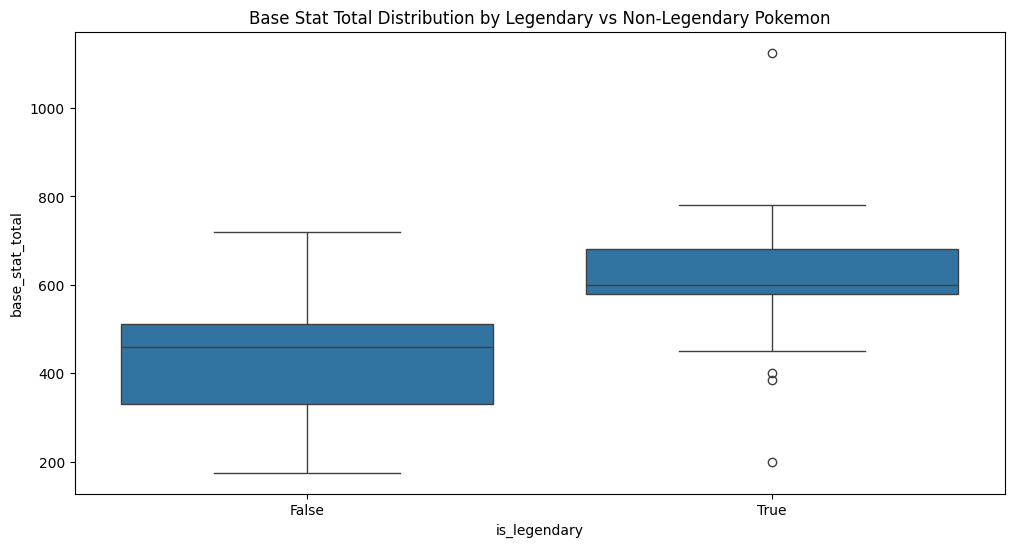

In [15]:
legendary_summary = (
    pokemon_df
    .groupby("is_legendary")[stat_cols]
    .mean()
    .round(2)
)

legendary_summary

plt.figure(figsize=(12,6))
sns.boxplot(data=pokemon_df, x="is_legendary", y="base_stat_total")
plt.title("Base Stat Total Distribution by Legendary vs Non-Legendary Pokemon")
plt.show()

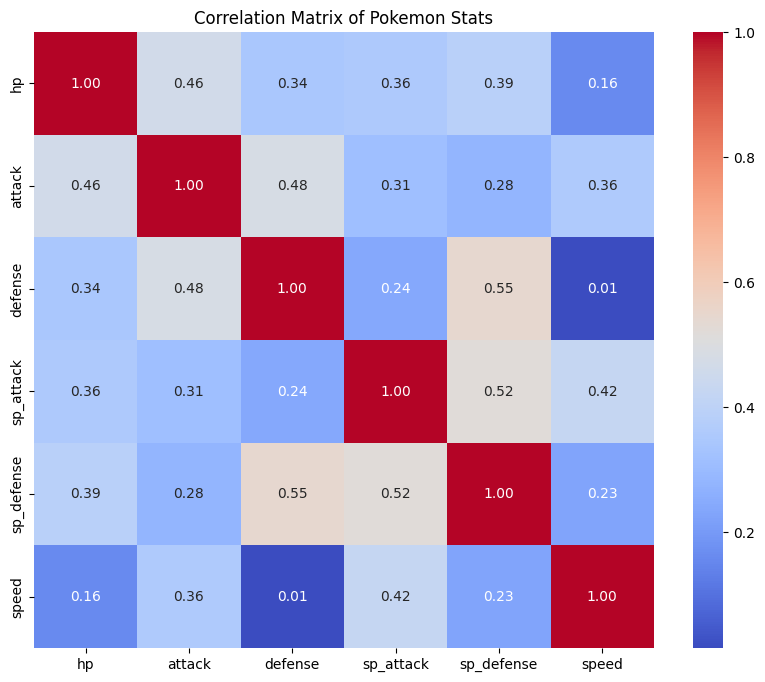

In [16]:
corr = pokemon_df[stat_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Pokemon Stats")
plt.show()

In [19]:
processed_path = ROOT_DIR / "data" / "processed" / "pokemon_with_matchups.json"

pokemon_final_df = pd.read_json(processed_path)

pokemon_final_df.head()

,pokedex_number,name,type_1,type_2,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,height_m,weight_kg,is_legendary,base_experience,abilities,generation,is_mythical,is_baby,color,shape,habitat,growth_rate,capture_rate,base_happiness,genus,evolution_chain_id,flavor_text,sprite_url,offense_score,defense_score,bulk_score,speed_score,physical_special_gap,primary_attack_style,role,defensive_matchups,weaknesses_4x,weaknesses_2x,resistances_0.5x,resistances_0.25x,immunities_0x,offensive_coverage,weakness_count,resistance_count,immunity_count,offensive_coverage_count
0,1,Bulbasaur,grass,poison,45,49,49,65,65,45,318,0.7,6.9,False,64.0,"[overgrow, chlorophyll]",NaN,False,False,green,quadruped,grassland,medium-slow,45,70,Seed Pokémon,1,A strange seed was planted on its back at birth. The plant sprouts and grows with this POKéMON.,https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/1.png,65,65,53.00,45,16,special,Generalist,"{'bug': 1.0, 'dark': 1.0, 'dragon': 1.0, 'electric': 0.5, 'fairy': 0.5, 'fighting': 0.5, 'fire': 2.0, 'flying': 2.0,...",[],"[fire, flying, ice, psychic]","[electric, fairy, fighting, water]",[grass],[],"{'super_effective_against': ['fairy', 'grass', 'ground', 'rock', 'water'], 'not_very_effective_against': ['bug', 'dr...",4,5,0,5
1,2,Ivysaur,grass,poison,60,62,63,80,80,60,405,1.0,13.0,False,142.0,"[overgrow, chlorophyll]",NaN,False,False,green,quadruped,grassland,medium-slow,45,70,Seed Pokémon,1,"When the bulb on its back grows large, it appears to lose the ability to stand on its hind legs.",https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/2.png,80,80,67.67,60,18,special,Generalist,"{'bug': 1.0, 'dark': 1.0, 'dragon': 1.0, 'electric': 0.5, 'fairy': 0.5, 'fighting': 0.5, 'fire': 2.0, 'flying': 2.0,...",[],"[fire, flying, ice, psychic]","[electric, fairy, fighting, water]",[grass],[],"{'super_effective_against': ['fairy', 'grass', 'ground', 'rock', 'water'], 'not_very_effective_against': ['bug', 'dr...",4,5,0,5
2,3,Venusaur,grass,poison,80,82,83,100,100,80,525,2.0,100.0,False,236.0,"[overgrow, chlorophyll]",NaN,False,False,green,quadruped,grassland,medium-slow,45,70,Seed Pokémon,1,The plant blooms when it is absorbing solar energy. It stays on the move to seek sunlight.,https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/3.png,100,100,87.67,80,18,special,Special Tank,"{'bug': 1.0, 'dark': 1.0, 'dragon': 1.0, 'electric': 0.5, 'fairy': 0.5, 'fighting': 0.5, 'fire': 2.0, 'flying': 2.0,...",[],"[fire, flying, ice, psychic]","[electric, fairy, fighting, water]",[grass],[],"{'super_effective_against': ['fairy', 'grass', 'ground', 'rock', 'water'], 'not_very_effective_against': ['bug', 'dr...",4,5,0,5
3,4,Charmander,fire,NaN,39,52,43,60,50,65,309,0.6,8.5,False,62.0,"[blaze, solar-power]",NaN,False,False,red,upright,mountain,medium-slow,45,70,Lizard Pokémon,2,"Obviously prefers hot places. When it rains, steam is said to spout from the tip of its tail.",https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/4.png,60,50,44.00,65,8,special,Generalist,"{'bug': 0.5, 'dark': 1.0, 'dragon': 1.0, 'electric': 1.0, 'fairy': 0.5, 'fighting': 1.0, 'fire': 0.5, 'flying': 1.0,...",[],"[ground, rock, water]","[bug, fairy, fire, grass, ice, steel]",[],[],"{'super_effective_against': ['bug', 'grass', 'ice', 'steel'], 'not_very_effective_against': ['dragon', 'fire', 'rock...",3,6,0,4
4,5,Charmeleon,fire,NaN,58,64,58,80,65,80,405,1.1,19.0,False,142.0,"[blaze, solar-power]",NaN,False,False,red,upright,mountain,medium-slow,45,70,Flame Pokémon,2,"When it swings its burning tail, it elevates the temperature to unbearably high levels.",https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/5.png,80,65,60.33,80,16,special,Generalist,"{'bug': 0.5, 'dark': 1.0, 'dragon': 1.0, 'electric': 1.0, 'fairy': 0.5, 'fighting': 1.0, 'fire': 0.5, 'flying': 1.0,...",[],"[ground, rock, water]","[bug, fairy, fire, grass, ice, steel]",[],[],"{'super_effe

,role,count
0,Generalist,426
1,Attacker,147
2,Physical Tank,137
3,Physical Sweeper,135
4,Defensive Wall,113
5,Balanced Fighter,112
6,Special Sweeper,97
7,Special Tank,80
8,Speed Utility,44
9,Glass Cannon,42


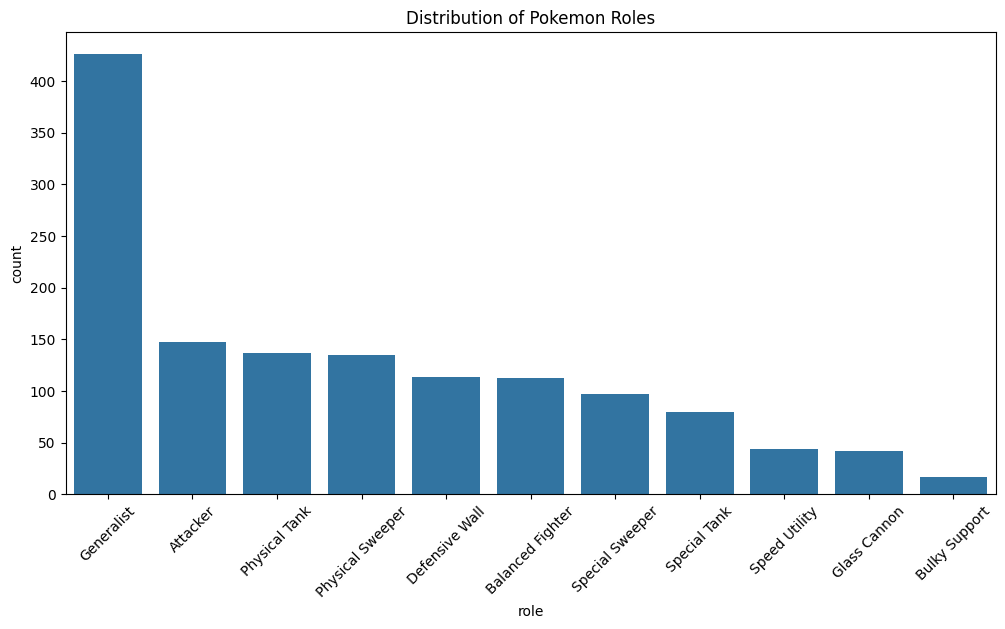

In [21]:
role_count = pokemon_final_df["role"].value_counts().reset_index()
role_count.columns = ["role", "count"]

display(role_count)

plt.figure(figsize=(12, 6))
sns.barplot(data=role_count, x='role', y='count')
plt.xticks(rotation=45)
plt.title('Distribution of Pokemon Roles')
plt.show()

In [24]:
pokemon_final_df[
    [
        "name",
        "type_1",
        "type_2",
        "weakness_count",
        "resistance_count",
        "immunity_count",
        "offensive_coverage_count",
    ]
].sort_values("weakness_count", ascending=False).head(20)

,name,type_1,type_2,weakness_count,resistance_count,immunity_count,offensive_coverage_count
1322,Barbaracle-Mega,rock,fighting,7,6,0,8
336,Lunatone,rock,psychic,7,5,0,6
892,Zarude,dark,grass,7,6,1,5
897,Calyrex,psychic,grass,7,6,0,5
907,Meowscarada,grass,dark,7,6,1,5
331,Cacturne,grass,dark,7,6,1,5
337,Solrock,rock,psychic,7,5,0,6
638,Terrakion,rock,fighting,7,6,0,8
1000,Wo-Chien,dark,grass,7,6,1,5
1084,Abomasnow-Mega,grass,ice,7,4,0,6


In [26]:
pokemon_final_df[
    pokemon_final_df["name"].str.lower() == "charizard"
][
    [
        "name",
        "type_1",
        "type_2",
        "role",
        "weaknesses_4x",
        "weaknesses_2x",
        "resistances_0.5x",
        "resistances_0.25x",
        "immunities_0x",
        "offensive_coverage",
    ]
]

,name,type_1,type_2,role,weaknesses_4x,weaknesses_2x,resistances_0.5x,resistances_0.25x,immunities_0x,offensive_coverage
5,Charizard,fire,flying,Special Sweeper,[rock],"[electric, water]","[fairy, fighting, fire, steel]","[bug, grass]",[ground],"{'super_effective_against': ['bug', 'fighting', 'grass', 'ice', 'steel'], 'not_very_effective_against': ['dragon', '..."
